# Image Stitching



In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

### Load Images

In [7]:
def display_images(img_path1, img_path2, output_file, image_number='4'):
    # Read the images using OpenCV
    img1 = cv2.imread(img_path1)
    img2 = cv2.imread(img_path2)

    # Convert BGR format (used by OpenCV) to RGB format (used by Matplotlib)
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # Create a new figure
    plt.figure(figsize=(10, 5))

    # Plot first image
    plt.subplot(1, 2, 1)
    plt.imshow(img1_rgb)
    first_img = f"Image {image_number}a"
    plt.title(first_img)
    plt.axis('off')  # Do not show axis values

    # Plot second image
    plt.subplot(1, 2, 2)
    plt.imshow(img2_rgb)
    second_img = f"Image {image_number}b"
    plt.title(second_img)
    plt.axis('off')  # Do not show axis values

    # Display the images
    plt.tight_layout()
    plt.savefig(output_file, bbox_inches='tight', pad_inches=0.1)
    plt.show()


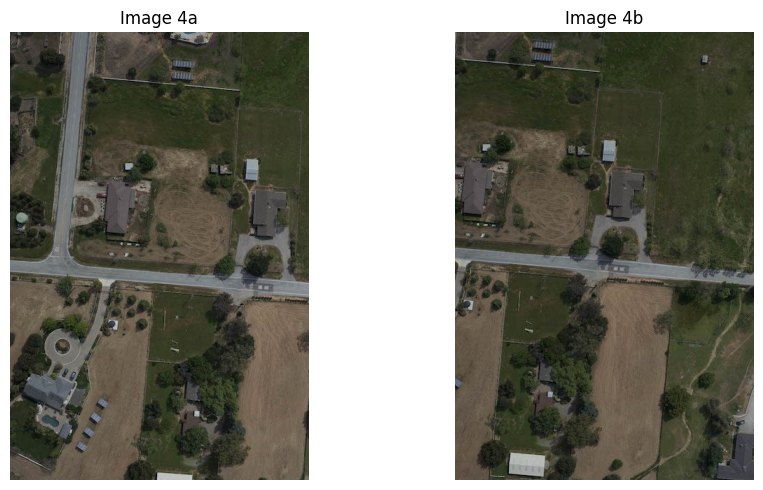

In [8]:
# display_images('/content/image pairs_01_01.jpg', '/content/image pairs_01_02.jpg', '1')
# display_images('/content/image pairs_02_01.png', '/content/image pairs_02_02.png', 'image_pair_02.png', '2')
# display_images('/content/image pairs_03_01.jpg', '/content/image pairs_03_02.jpg', 'image_pair_03.png', '3')
display_images('/content/image pairs_04_01.jpg', '/content/image pairs_04_02.jpg', 'image_pair_04.png', '4')



### Read all files in the folder

In [9]:
import os

def get_jpeg_files_in_folder(folder_path):
    jpeg_files = {}
    # jpeg_files = []

    if not os.path.exists(folder_path):
        print(f"The folder '{folder_path}' does not exist.")
        return jpeg_files

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpeg', '.jpg', '.png')):
            # jpeg_files.append(filename)
            file_path = f"{folder_path}/{filename}"

            image = cv2.imread(file_path)
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # print ('filepath', file_path)
            # new_file_name = Path(file_path).stem # only file name without extension
            # new_file_name = Path(file_path).name # include extension .jpg
            new_file_name = file_path # TODO: change
            jpeg_files[new_file_name] = rgb_image

    # return jpeg_files
    return dict(sorted(jpeg_files.items()))

In [10]:
# Example usage:
folder_path = 'imgs'
jpeg_files = get_jpeg_files_in_folder(folder_path)

image_names = list(jpeg_files.keys())
print (image_names)

#values saved are in RGB format

The folder 'imgs' does not exist.
[]


### Feature Detection & Mapping

Harris corner detection and SIFT

In [11]:
def harris(img_dir):
    img = cv2.imread(img_dir)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)  # Turn image to gray
    gray = np.float32(gray)
    harris = cv2.cornerHarris(gray,2,3,0.04)  # blockSize=2, ksize=3, k=0.04

    # Get coordinates of detected corners
    corner_coords = np.argwhere(harris>0.01*harris.max())

    # Result is dilated for marking the corners, not important
    harris = cv2.dilate(harris,None)

    # Threshold for an optimal value, it may vary depending on the image.
    img[harris>0.01*harris.max()]=[0,0,255]

    img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img_color, corner_coords # 2 outputs

In [12]:
# plot and save individual images

def harris_all_imgs(jpeg_files, save=False):
  image_names = list(jpeg_files.keys())
  print (image_names)

  fig, axes = plt.subplots(4, 2, figsize=(6, 10))
  axes = axes.ravel()

  for i, img in enumerate(image_names):
      outputs = harris(img)
      img_display = outputs[0]
      img_title = Path(img).stem
      axes[i].set_title(img_title)
      axes[i].imshow(img_display)

      # print(f"Coordinates for detected corners in Sample {img_title}")
      print(outputs[1])

  # Remove x and y ticks for a cleaner look
  for ax in axes.ravel():
      ax.axis('off')

  if save==True:
    file_name = "harris.png"
    # cv.imwrite('harris.png', cv2.cvtColor(he_rbg, cv.COLOR_RGB2BGR)
    plt.savefig(file_name, bbox_inches='tight', dpi=500)

  # Add spacing between subplots
  plt.tight_layout()
  # Display the figure
  plt.show()

# harris_all_imgs(jpeg_files, save=True)

## Image Stitching (default)

### Main SIFT, Homography Functions

In [14]:
def sift(imgdir,corner_loc):
    sift = cv2.xfeatures2d.SIFT_create()
    keypoints=[]
    img=cv2.imread(imgdir,0)
    if corner_loc is None:
      # corner_loc, if no custom keypoints were provided, will automatically detect and compute
      keypoints, descriptors = sift.detectAndCompute(img, None) # automatic detection
    else:
      for n in range(len(corner_loc)):
          kp = cv2.KeyPoint(float(corner_loc[n][1]),float(corner_loc[n][0]),10)
          keypoints.append(kp)

      keypoints, descriptors = sift.compute(img,keypoints)

    return keypoints, descriptors


def homography(descriptor1,keypoints1,descriptor2,keypoints2):
    matcher = cv2.BFMatcher()
    raw_matches = matcher.knnMatch(descriptor1, descriptor2, k=2)
    good_points = []
    good_matches=[]
    for m1, m2 in raw_matches:
        if m1.distance < 0.85 * m2.distance:
            good_points.append((m1.trainIdx, m1.queryIdx))
            good_matches.append([m1])

    if len(good_points) > 8:
        image1_kp = np.float32(
            [keypoints1[i].pt for (_, i) in good_points])
        image2_kp = np.float32(
            [keypoints2[i].pt for (i, _) in good_points])

    (H, status) = cv2.findHomography(image2_kp, image1_kp, cv2.RANSAC, 5)

    return H, good_matches


def mask(img1,img2,version, smoothing_window_size):
    # smoothing_window_size=188 # use 188 for all images, for image 2, use 50
    height_img1 = img1.shape[0]
    width_img1 = img1.shape[1]
    width_img2 = img2.shape[1]
    height_panorama = height_img1
    width_panorama = width_img1 +width_img2
    offset = int(smoothing_window_size / 2)
    barrier = img1.shape[1] - int(smoothing_window_size / 2)
    mask = np.zeros((height_panorama, width_panorama))
    if version== 'left_image':
        mask[:, barrier - offset:barrier + offset ] = np.tile(np.linspace(1, 0, 2 * offset ).T, (height_panorama, 1))
        mask[:, :barrier - offset] = 1
    else:
        mask[:, barrier - offset :barrier + offset ] = np.tile(np.linspace(0, 1, 2 * offset ).T, (height_panorama, 1))
        mask[:, barrier + offset:] = 1
    return cv2.merge([mask, mask, mask])


def blending(img1,img2,H, smoothing_window_size=188):
    height_img1 = img1.shape[0]
    width_img1 = img1.shape[1]
    width_img2 = img2.shape[1]
    height_panorama = height_img1
    width_panorama = width_img1 +width_img2

    panorama1 = np.zeros((height_panorama, width_panorama, 3))
    mask1 = mask(img1,img2,version='left_image', smoothing_window_size=smoothing_window_size)
    panorama1[0:img1.shape[0], 0:img1.shape[1], :] = img1
    panorama1 *= mask1
    mask2 = mask(img1,img2,version='right_image', smoothing_window_size=smoothing_window_size)
    panorama2 = cv2.warpPerspective(img2, H, (width_panorama, height_panorama))*mask2
    result=panorama1+panorama2

    # Get rid of black borders created by perspective differences and unused space
    rows, cols = np.where(result[:, :, 0] != 0) # Check if a pixel is pure black or not (0-255) and get the ones that are not black as rows and cols
    min_row, max_row = min(rows), max(rows) + 1
    min_col, max_col = min(cols), max(cols) + 1
    final_result = result[min_row:max_row, min_col:max_col, :] # Resize image without black borders

    return final_result

### Plot Figures

In [15]:
def plot_matches(img1,keypoints1,img2,keypoints2, good_matches, img_name, save=True):
  plt.figure(figsize=(10, 10))

  temp_file_name = Path(img_name).stem
  file_name = f"{temp_file_name[:-3]}"

  draw_params = dict(matchColor = (0,0,255), singlePointColor = None,
                  flags = 2)
  img3 = cv2.drawMatchesKnn(img1,keypoints1,img2,keypoints2, good_matches, None,**draw_params)
  img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

  plt.imshow(img3)
  if save:
      plt.savefig(f'{file_name}-matches.png', bbox_inches='tight', dpi=300)
  # plt.show()

In [16]:
def save_final_img(img_name, image_result):

  plt.figure(figsize=(10, 10))

  temp_file_name = Path(img_name).stem
  file_name = f"{temp_file_name[:-3]}-result.png"

  print (f'Saving Final Result... {file_name}')

  plt.imshow(image_result)
  plt.savefig(file_name, bbox_inches='tight', dpi=300)


### Main Run Function

Use sift with custom keypoints (e.g. Harris Window) detected or automatic keypoints (within the library).

In [35]:
def image_stitch(imgdir1,imgdir2, save=True, smoothing_window_size=188):
    #Intialize variables
    keypoints={}
    descriptors={}

    corner_loc1=harris(imgdir1)
    corner_loc2=harris(imgdir2)

    keypoints1, descriptors1=sift(imgdir1,corner_loc1[1])
    keypoints2, descriptors2=sift(imgdir2,corner_loc2[1])
    ## Use these 2 lines if want to use SIFT keypoints default
    # keypoints1, descriptors1=sift(imgdir1,None)
    # keypoints2, descriptors2=sift(imgdir2,None)

    #Get homography matrix
    H, good_matches = homography(descriptors1,keypoints1,descriptors2,keypoints2)

    #Load images
    img1 = cv2.imread(imgdir1)
    img2 = cv2.imread(imgdir2)

    plot_matches(img1,keypoints1,img2,keypoints2, good_matches, imgdir1, save) # show matches

    #Create composite image
    result = blending(img1,img2,H, smoothing_window_size=smoothing_window_size)
    result = result.astype(np.uint8)
    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    # save final result
    if save:
      save_final_img(imgdir1, result)
    return result

Saving Final Result... image pairs_01-result.png
Saving Final Result... image pairs_02-result.png
Saving Final Result... image pairs_03-result.png
Saving Final Result... image pairs_04-result.png


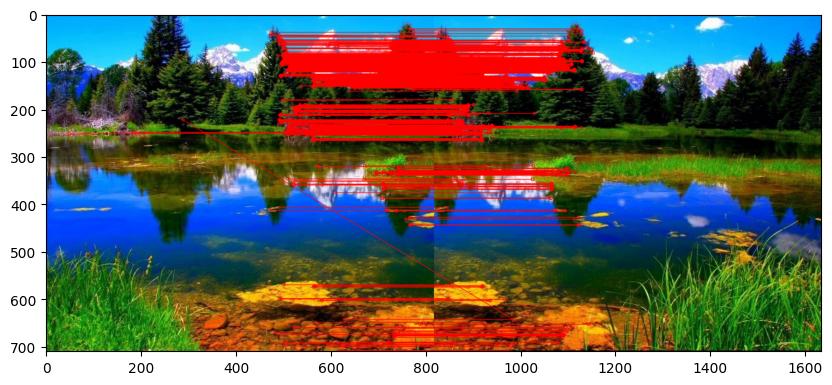

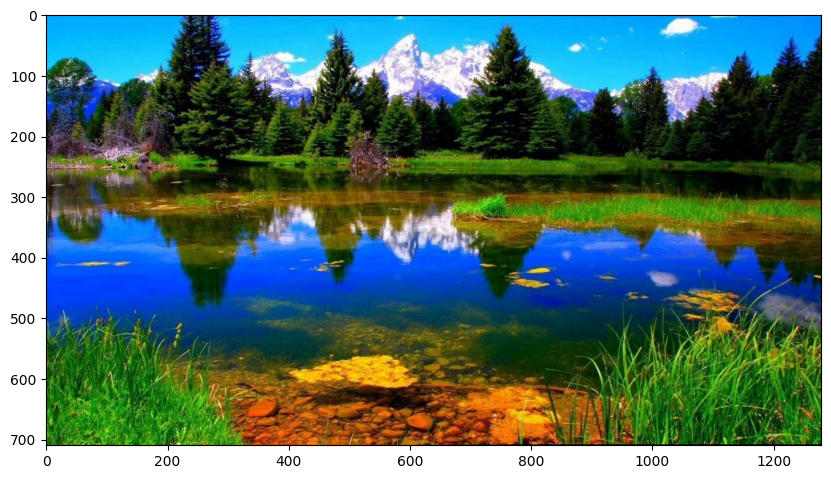

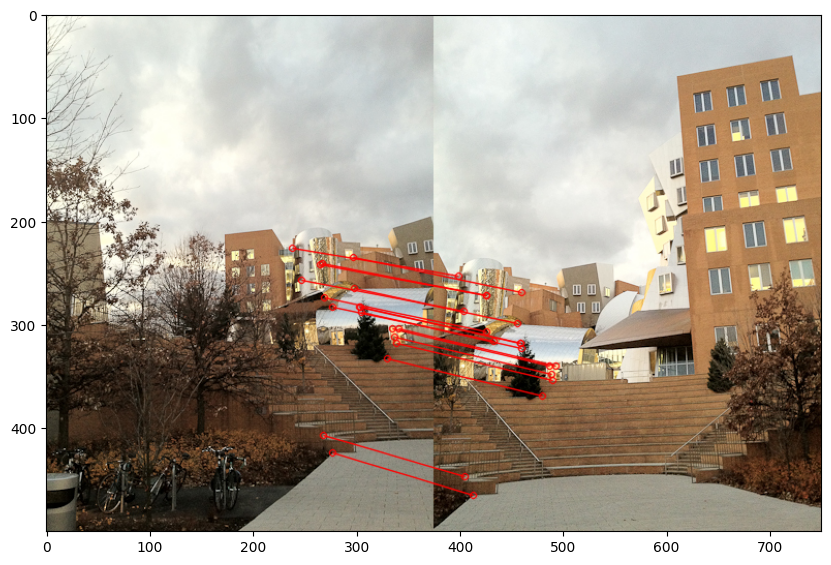

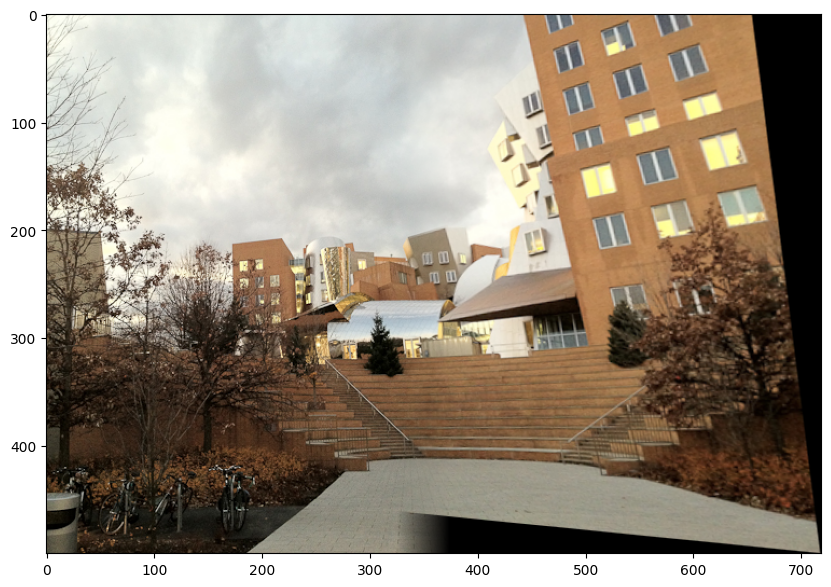

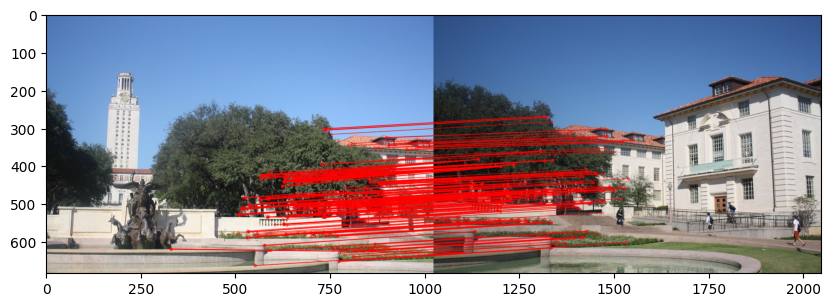

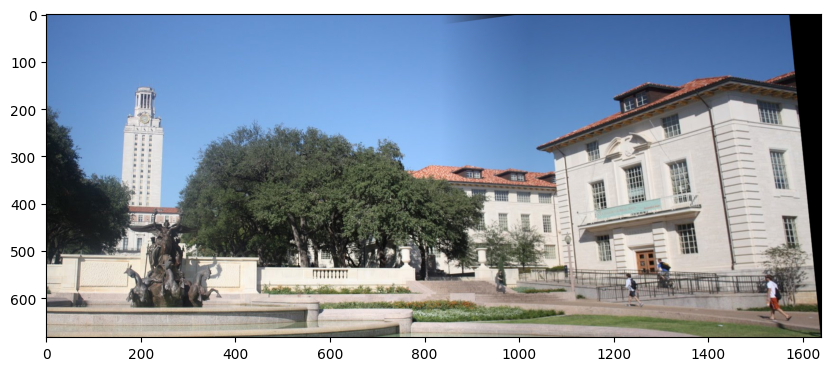

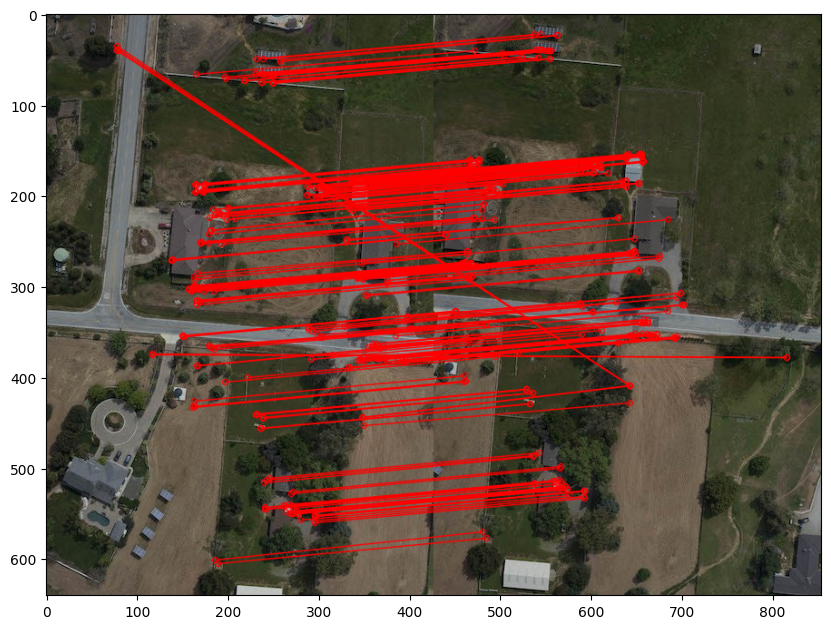

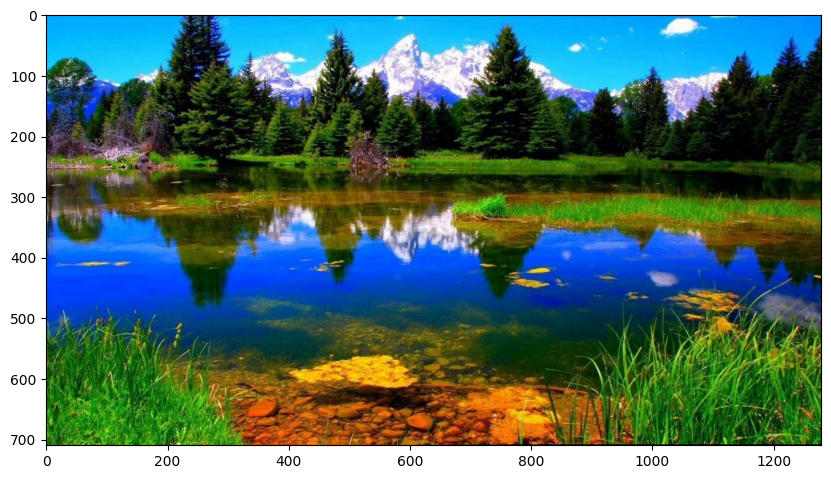

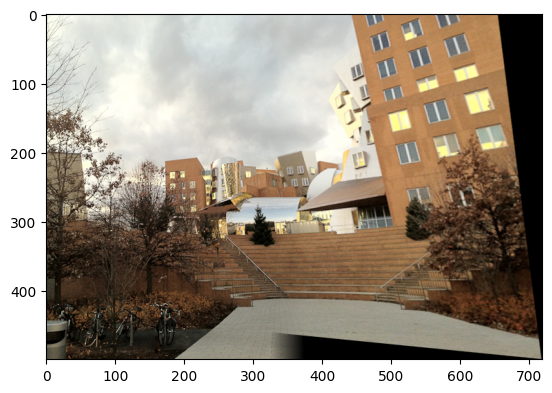

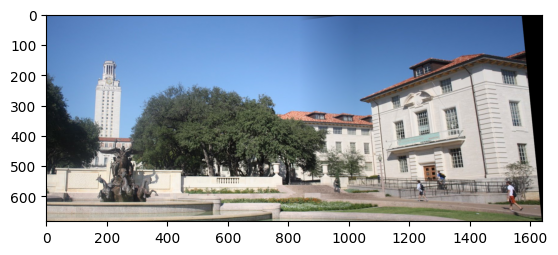

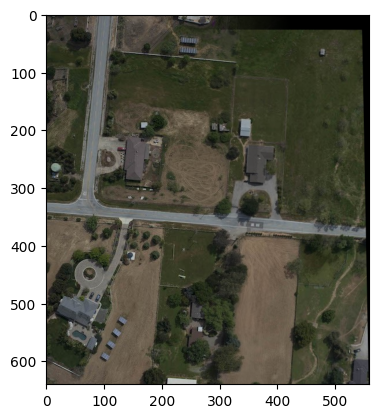

In [36]:
result1 = image_stitch("/content/image pairs_01_01.jpg", "/content/image pairs_01_02.jpg")
result2 = image_stitch("/content/image pairs_02_02.png", "/content/image pairs_02_01.png", smoothing_window_size=50)
result3 = image_stitch("/content/image pairs_03_01.jpg", "/content/image pairs_03_02.jpg")
result4 = image_stitch("/content/image pairs_04_01.jpg", "/content/image pairs_04_02.jpg")

plt.imshow(result1)
plt.show()

plt.imshow(result2)
plt.show()

plt.imshow(result3)
plt.show()

plt.imshow(result4)
plt.show()

In [20]:
import imutils

def crop_and_transform(stitched):

    stitched = cv2.copyMakeBorder(stitched, 10, 10, 10, 10,
            cv2.BORDER_CONSTANT, (0, 0, 0))

    # convert the stitched image to grayscale and threshold it
    # such that all pixels greater than zero are set to 255
    # (foreground) while all others remain 0 (background)
    gray = cv2.cvtColor(stitched, cv2.COLOR_BGR2GRAY)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)[1]

    # find all external contours in the threshold image then find
    # the *largest* contour which will be the contour/outline of
    # the stitched image
    contours = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE)
    contours = imutils.grab_contours(contours)

    # THIS IS IMPORTANT - fills all the gaps with white pixel within the contour
    for c in contours:
      cv2.drawContours(thresh,[c], 0, (255,255,255), -1)

    c = max(contours, key=cv2.contourArea)

    mask = np.zeros(thresh.shape, dtype="uint8")
    (x, y, w, h) = cv2.boundingRect(c)
    cv2.rectangle(mask, (x, y), (x + w, y + h), 255, -1)

    minRect = mask.copy()
    sub = mask.copy()

    # subtracted image
    while cv2.countNonZero(sub) > 0:
        # erode the minimum rectangular mask and then subtract
        # the thresholded image from the minimum rectangular mask
        # so we can count if there are any non-zero pixels left
        minRect = cv2.erode(minRect, None)
        sub = cv2.subtract(minRect, thresh)

    contours = cv2.findContours(minRect.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = imutils.grab_contours(contours)
    c = max(contours, key=cv2.contourArea)
    (x, y, w, h) = cv2.boundingRect(c)

    stitched = stitched[y:y + h, x:x + w]

    return stitched


In [33]:
bgr_1 = cv2.cvtColor(result1, cv2.COLOR_RGB2BGR)
new_result_1 = crop_and_transform(bgr_1)

bgr_2 = cv2.cvtColor(result2, cv2.COLOR_RGB2BGR)
new_result_2 = crop_and_transform(bgr_2)

bgr_3 = cv2.cvtColor(result3, cv2.COLOR_RGB2BGR)
new_result_3= crop_and_transform(bgr_3)

bgr_4 = cv2.cvtColor(result4, cv2.COLOR_RGB2BGR)
new_result_4 = crop_and_transform(bgr_4)


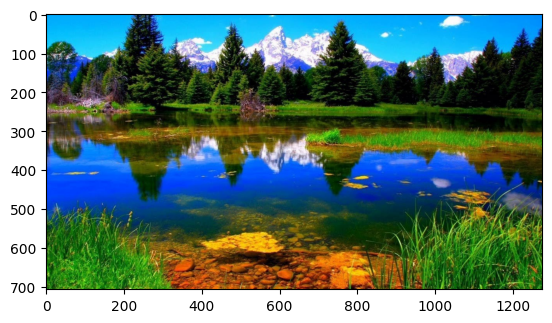

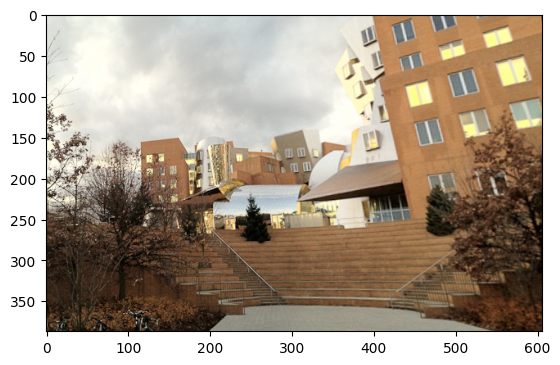

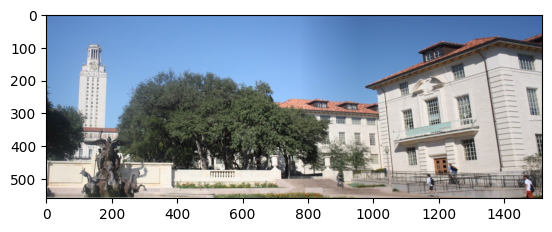

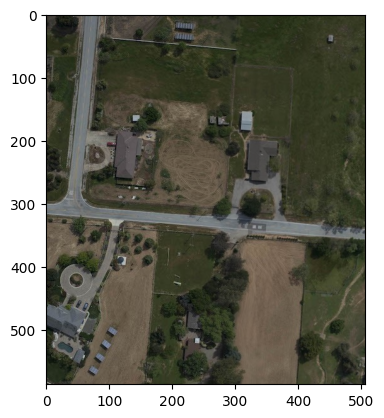

In [34]:
# Display the result

plt.imshow(cv2.cvtColor(new_result_1, cv2.COLOR_BGR2RGB))
plt.show()

plt.imshow(cv2.cvtColor(new_result_2, cv2.COLOR_BGR2RGB))
plt.show()

plt.imshow(cv2.cvtColor(new_result_3, cv2.COLOR_BGR2RGB))
plt.show()

# new_result_4 = cv2.rotate(new_result_4, cv2.ROTATE_90_CLOCKWISE)
plt.imshow(cv2.cvtColor(new_result_4, cv2.COLOR_BGR2RGB))
plt.show()